### Pupil design

Designing a pupil structure (transmittance and wavefront error) is essential for an accurate point-spread function modeling. `jasmine_toolkit` provides functions to simulate the entrance pupil. This notebook describes a quick tutorial for these functions.

In [1]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['figure.constrained_layout.use'] = True

A submodule `optics` contains functions for the pupil simulation.

In [2]:
import jasmine_toolkit.optics as optics
import astropy.units as u
import numpy as np

#### Obscuration

First, we introduce a function to simulate the obscuration by the secondary mirror and its supports. `get_obscuration` function returns an optical element defined in [POPPY][1], an optics simulation package in Python. We can specify the radius of the obscuration disk, the number of the supports, and the width of the supports. These values are retrieved from `parameters` if not specified.

[1]: https://poppy-optics.readthedocs.io/en/latest/index.html

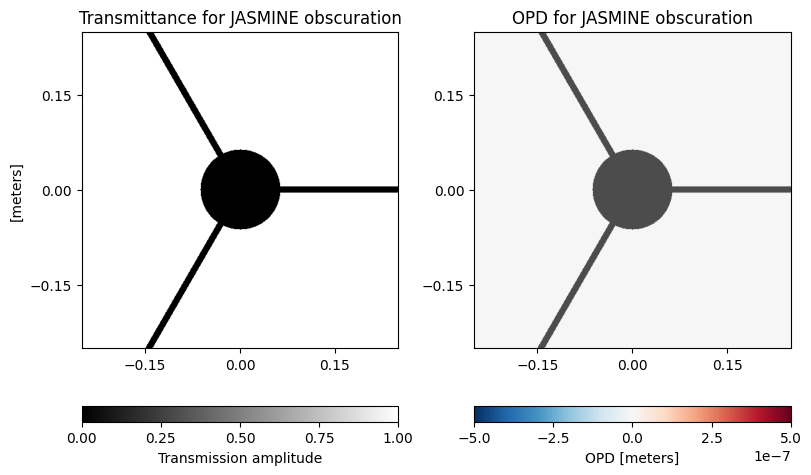

In [3]:
fig = plt.figure(figsize=(8, 7))

layer = optics.get_obscuration()
layer.display(what='both', grid_size=0.5 * u.m)

plt.show()

`get_obscuration` produces a shadow of the structure on the entrance pupil. Thus, the shadow can move on the pupil plane when an incident light is different from the optical axis. By default, we assume that the obscuration layer is located 227 mm before the entrance pupil. The thickness of the obscuration layer is tentatively set 50 mm. The example code below demonstrates the geometrical effect. The obscuration disk is shifted toward ${+}x$ and the shadows are horizontally expanded.

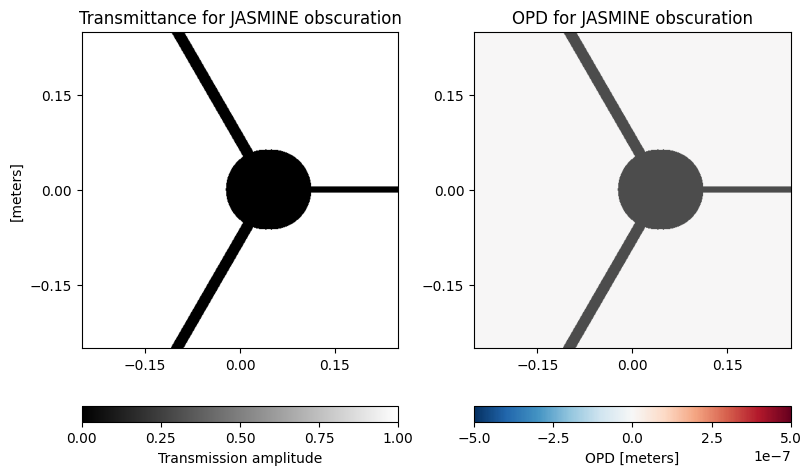

In [4]:
fig = plt.figure(figsize=(8, 7))

layer = optics.get_obscuration(xan=10 * u.deg, yan=0 * u.deg)
layer.display(what='both', grid_size=0.5*u.m)

plt.show()

#### Wavefront error

The toolkit contains a wavefront error file obtained by optics simulation via CodeV. The wavefront errors are evaluated in 21&times;21 directions. The function `get_wfe_fringe37` returns a wavefront error instance based on the optics simulation.

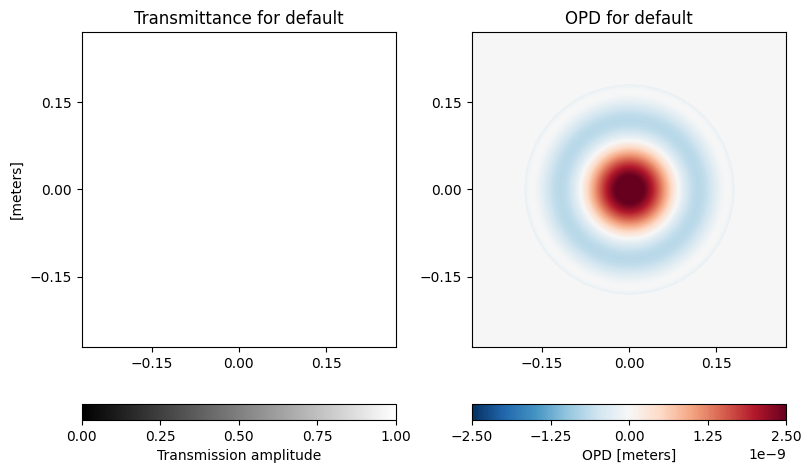

In [5]:
fig = plt.figure(figsize=(8, 7))

wfe = optics.get_wfe_fringe37()
wfe.wfe.display(npix=512, opd_vmax=2.5e-9 * u.meter, what='both')

plt.show()

We can specify the direction of an incident light. The function interpolate the wavefront errors evaluated in the grid.

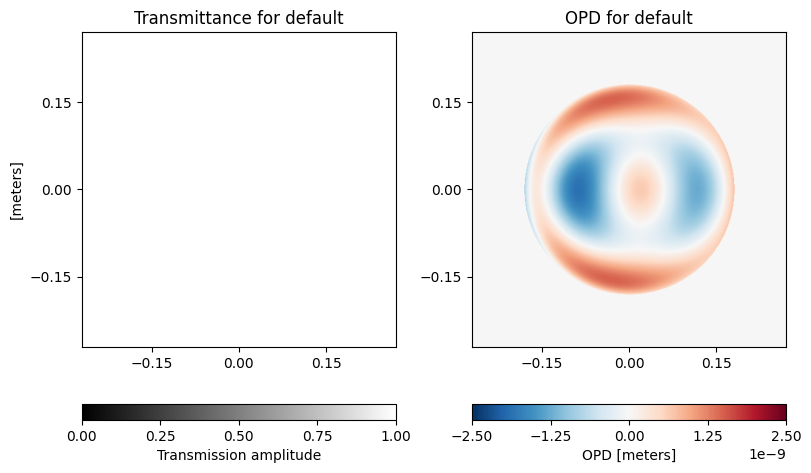

In [6]:
fig = plt.figure(figsize=(8, 7))

wfe = optics.get_wfe_fringe37(xan=0.3 * u.deg, yan=0.0 * u.deg)
wfe.wfe.display(npix=512, opd_vmax=2.5e-9 * u.meter, what='both')

plt.show()

#### Pupil design

The function `get_pupil` returns a pupil design with the obscuration and wavefront error.

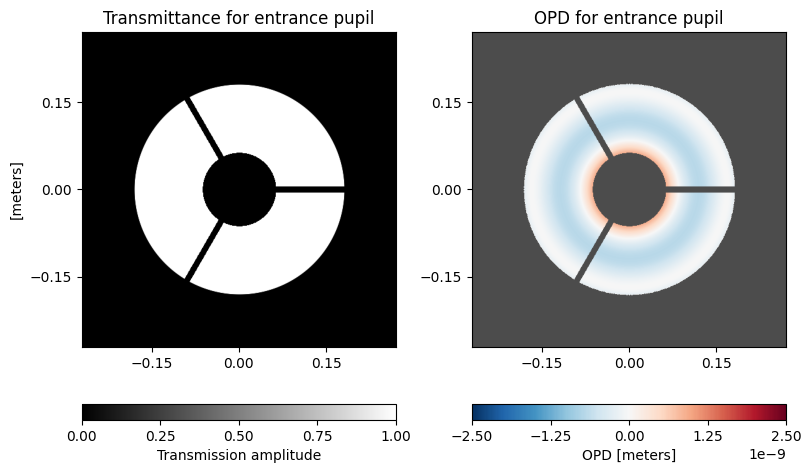

In [7]:
fig = plt.figure(figsize=(8, 7))

pupil = optics.get_pupil()
pupil.display(what='both', opd_vmax=2.5e-9 * u.m)

plt.show()

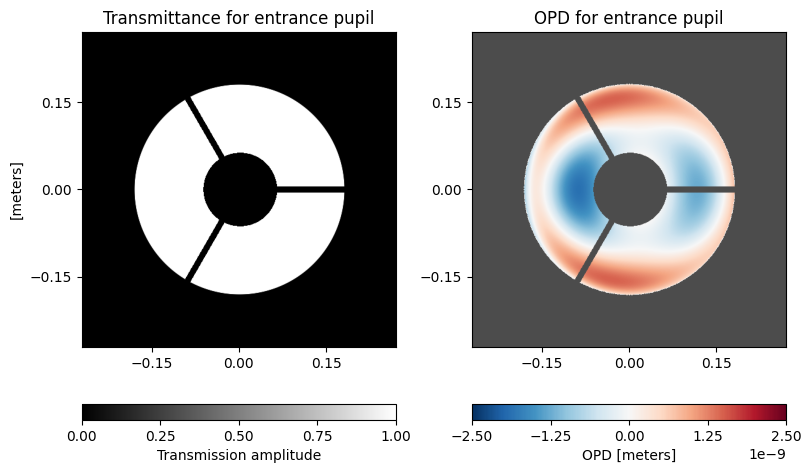

In [8]:
fig = plt.figure(figsize=(8, 7))

pupil = optics.get_pupil(xan=0.3 * u.deg, yan=0.0 * u.deg)
pupil.display(what='both', opd_vmax=2.5e-9 * u.m)

plt.show()

#### Point-spread function

A point-spread function (PSF) can be quickly evaluated using a designed pupil.

In [9]:
import jasmine_toolkit.parameters as p
import poppy

osys = poppy.OpticalSystem()
osys.add_pupil(optics.get_pupil())
osys.add_detector(
  pixelscale=p.detector.pixel_scale, fov_pixels=25, oversample=11)

osys.describe()

	Pupil plane: entrance pupil
	Detector plane: Detector (25x25 pixels, 0.000 deg / pix)


Now, we integrate monochromatic PSFs over 0.9&ndash;1.6 &mu;m.

In [10]:
wavelength = np.linspace(0.9, 1.6, 11) * u.um
psf = osys.calc_psf(wavelength=wavelength)

The simulated PSF is illustrated below in a logarithmic scale.

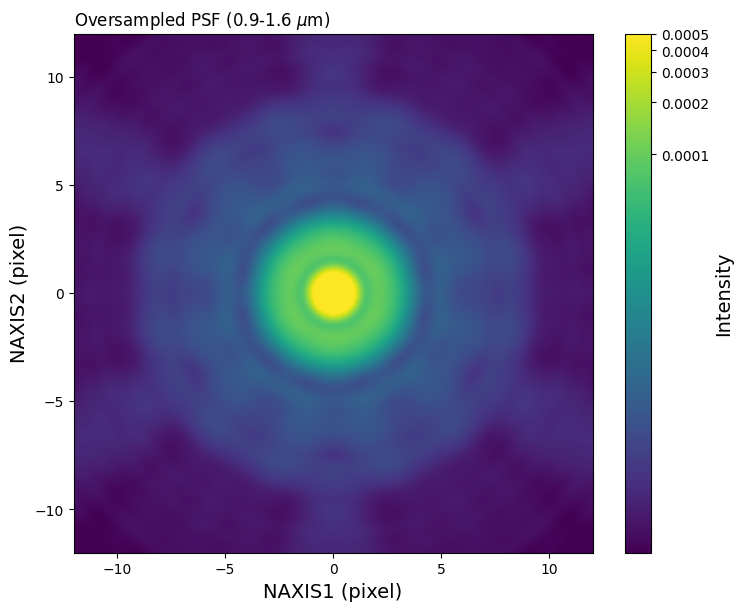

In [11]:
from astropy.visualization import simple_norm

fig, ax = plt.subplots(figsize=(8, 6))

norm = simple_norm(psf[0].data, 'log', percent=99)
h = ax.imshow(
  psf[0].data, norm=norm, extent=[-12, 12] * 2)
fig.colorbar(h).set_label('Intensity', fontsize=14)

ax.set_title('Oversampled PSF (0.9-1.6 $\mu$m)', loc='left', fontsize=12)
ax.set_xlabel('NAXIS1 (pixel)', fontsize=14)
ax.set_ylabel('NAXIS2 (pixel)', fontsize=14)

plt.show()